In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

from matplotlib import patches

from youngs_modulus_utils import *

torch.manual_seed(67)

In [2]:
class NN(torch.nn.Module):
    def __init__(self, input_dim, output_dim, layers, neurons, activation = 'tanh'):
        super(NN, self).__init__()
        self.activation = activation

        self.input_layer   = torch.nn.Linear(input_dim, neurons, bias = True)
        self.hidden_layers = torch.nn.ModuleList([torch.nn.Linear(neurons, neurons, bias = True) for _ in range(layers)])
        self.output_layer  = torch.nn.Linear(neurons, output_dim, bias = True)
        
        if self.activation == 'tanh':
            self.act = nn.Tanh()
        elif self.activation == 'relu':
            self.act = nn.ReLU()
        elif self.activation == 'gelu':
            self.act = nn.GELU()
        elif self.activation == 'sin':
            self.act = torch.sin  
        else:
            raise ValueError(f"Unknown activation: {activation}")
    
    def forward(self, x):
        a =  self.input_layer(x)
        for l in self.hidden_layers:
            a = self.act(l(a))
        return self.output_layer(a)
    
    
    def init_xavier(self):
        def init_weights(m):
            if type(m) == nn.Linear and m.weight.requires_grad and m.bias.requires_grad:
                if self.activation == 'sin':
                    nn.init.xavier_uniform_(m.weight)
                else:
                    g = nn.init.calculate_gain(self.activation)
                    torch.nn.init.xavier_uniform_(m.weight, gain=g)
                m.bias.data.fill_(0)
        self.apply(init_weights)

sum(p.numel() for p in NN(5, 5, 5, 5).parameters())

210

In [3]:
BATCH_SIZE = 32

In [4]:
domain = torch.tensor([[0, 1], [0, 2]]) # x = [0, 1]; t = [0, 2]
sobol_engine = torch.quasirandom.SobolEngine(dimension = 2) # x and t

class dataset(torch.utils.data.Dataset):
    def __init__(self, engine: torch.quasirandom.SobolEngine, draw: int):
        self.data = engine.draw(draw) 

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        return self.data[index]
    
train_dataset_obj = dataset(sobol_engine, 1000)
train_dataloader = torch.utils.data.DataLoader(train_dataset_obj, batch_size = BATCH_SIZE, shuffle = True)

test_dataset_obj = dataset(sobol_engine, 500)
test_dataloader = torch.utils.data.DataLoader(test_dataset_obj, batch_size = BATCH_SIZE, shuffle = True)

next(iter(test_dataloader)).shape

torch.Size([32, 2])

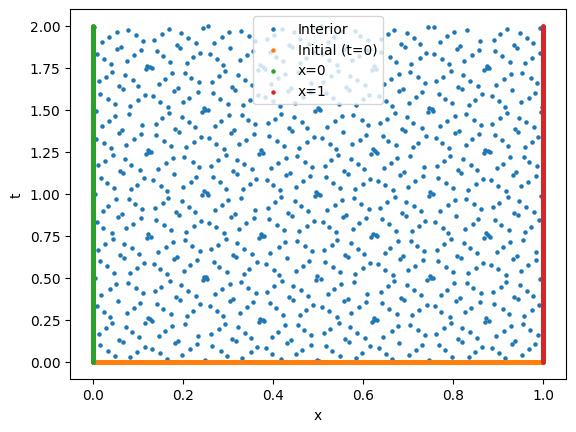

In [5]:
domain = torch.tensor([[0, 1], [0, 2]]) # x = [0, 1]; t = [0, 2]
sobol_engine = torch.quasirandom.SobolEngine(dimension = 2) # x and t

def u_0(x):
    return torch.sin(5*x) + torch.sin(10*x) #+ torch.exp(x)

def v_0(x):
    return torch.cos(10*x)# + torch.exp(-x)
    
def get_interior(data, domain):
    data = data.clone()
    data[:, 0] =  domain[0][0] + (domain[0][1] - domain[0][0]) * data[:, 0]
    data[:, 1] =  domain[1][0] + (domain[1][1] - domain[1][0]) * data[:, 1]
    return data

def get_BC(data, domain):
    data = data.clone()
    data[:,1] = domain[1][0] + (domain[1][1] - domain[1][0]) * data[:,1]

    # x = 0
    data_0 = data.clone()
    data_0[:,0] = domain[0][0]

    # x = L
    data_L = data.clone()
    data_L[:,0] = domain[0][1]

    return data_0, data_L

def get_initial(data, domain, u_0, v_0):
    data = data.clone()
    data[:,0] = domain[0][0] + (domain[0][1] - domain[0][0]) * data[:,0]

    data[:, 1] = 0 # t = 0 

    x = data[:,0]
    u = u_0(x)
    u_t = v_0(x)

    u = torch.stack((u, torch.zeros_like(u)), dim=1)
    u_t = torch.stack((u_t, torch.zeros_like(u_t)), dim=1)

    return data, u, u_t


# plotting
dummy_data = []

for d in train_dataloader:
    dummy_data.append(d)
    
data = torch.cat(dummy_data, dim = 0)

interior = get_interior(data, domain)
ic_coords, _, _ = get_initial(data, domain, u_0, v_0)
bc_0, bc_L = get_BC(data, domain)

plt.figure()
plt.scatter(interior[:,0], interior[:,1], s=5, label="Interior")
plt.scatter(ic_coords[:,0], ic_coords[:,1], s=5, label="Initial (t=0)")

plt.scatter(bc_0[:,0], bc_0[:,1], s=5, label="x=0")
plt.scatter(bc_L[:,0], bc_L[:,1], s=5, label="x=1")

plt.legend()
plt.xlabel("x")
plt.ylabel("t")
plt.show()

In [6]:
# interior_data = get_interior(sobol_engine, 10)

def get_interior_residual(u_model, E_model, points):
    points.requires_grad_(True)

    u = u_model(points)

    grad_u = torch.autograd.grad(u.sum(), points, create_graph=True)[0]
    u_x = grad_u[:, 0]
    u_t = grad_u[:, 1]

    u_tt = torch.autograd.grad(u_t.sum(), points, create_graph=True)[0][:, 1]
    E = E_model(u_x.unsqueeze(1)).squeeze()

    # flux = E(u_x) * u_x
    flux = E * u_x

    flux_x = torch.autograd.grad(
        flux.sum(), points, create_graph=True
    )[0][:, 0]

    interior_residual = u_tt - flux_x

    return interior_residual

def get_IC_residue(u_model, points):

    coords  = points[0].clone().detach().requires_grad_(True) # (x, 0)
    u_0     = points[1].clone().detach().requires_grad_(True) # u(x,0)
    u_t     = points[2].clone().detach().requires_grad_(True) # u_t(x,0)

    u_pred = u_model(coords) 
    ic_1_residue = u_pred - u_0

    grad_u = torch.autograd.grad(
        u_pred.sum(), coords, create_graph=True
    )[0]
    u_t_pred = grad_u[:, 1].unsqueeze(1)
    ic_2_residue = u_t_pred - u_t
    return ic_1_residue, ic_2_residue

def get_BC_residue(u_model, points):
    return u_model(points[0]),  u_model(points[1])

In [7]:
lr = 1e-3
print("Without learning rate annealing")
u_predictor_model = NN(input_dim = 2, output_dim = 1, layers = 8, neurons = 128)
E_predictor_model = NN(input_dim = 1, output_dim = 1, layers = 8, neurons = 128)
optimizer = torch.optim.Adam(
    list(u_predictor_model.parameters()) + 
    list(E_predictor_model.parameters()),
    lr=lr
)

wo_epoch_loss_track, wo_epoch_loss_track_test, wo_residue_tracker, wo_grad_tracker, wo_lambda_tracker = train(
                                                                                           epochs = 100, optimizer = optimizer, 
                                                                                           u_predictor_model = u_predictor_model, 
                                                                                           E_predictor_model = E_predictor_model, 
                                                                                           train_dataloader = train_dataloader, test_dataloader = test_dataloader, 
                                                                                           get_interior = get_interior, get_initial = get_initial, get_BC = get_BC,
                                                                                           get_interior_residual = get_interior_residual, get_IC_residue = get_IC_residue, get_BC_residue = get_BC_residue, 
                                                                                           domain = domain,
                                                                                           u_0 = u_0, v_0 = v_0,
                                                                                           lr_annealing_decay = False,
                                                                                           initial_lr=lr,
                                                                                           lambda_scaling = False
                                                                                           )

print("\n\nWith learning rate annealing")
u_predictor_model = NN(input_dim = 2, output_dim = 1, layers = 8, neurons = 128)
E_predictor_model = NN(input_dim = 1, output_dim = 1, layers = 8, neurons = 128)
optimizer = torch.optim.Adam(
    list(u_predictor_model.parameters()) + 
    list(E_predictor_model.parameters()),
    lr=lr
)
w_epoch_loss_track, w_epoch_loss_track_test, w_residue_tracker, w_grad_tracker, w_lambda_tracker = train(
                                                                                           epochs = 100, optimizer = optimizer, 
                                                                                           u_predictor_model = u_predictor_model, 
                                                                                           E_predictor_model = E_predictor_model, 
                                                                                           train_dataloader = train_dataloader, test_dataloader = test_dataloader, 
                                                                                           get_interior = get_interior, get_initial = get_initial, get_BC = get_BC,
                                                                                           get_interior_residual = get_interior_residual, get_IC_residue = get_IC_residue, get_BC_residue = get_BC_residue, 
                                                                                           domain = domain,
                                                                                           u_0 = u_0, v_0 = v_0,
                                                                                           lr_annealing_decay = True,
                                                                                           initial_lr=lr,
                                                                                           lambda_scaling = False
                                                                                           )

Without learning rate annealing
EPOCH: 1 | train loss: 0.6271 | test loss: 0.6190
EPOCH: 11 | train loss: 0.4449 | test loss: 0.4569
EPOCH: 21 | train loss: 0.4319 | test loss: 0.4346
EPOCH: 31 | train loss: 0.4108 | test loss: 0.4016
EPOCH: 41 | train loss: 0.4159 | test loss: 0.4426
EPOCH: 51 | train loss: 0.3924 | test loss: 0.3910
EPOCH: 61 | train loss: 0.3744 | test loss: 0.3918
EPOCH: 71 | train loss: 0.3669 | test loss: 0.3628
EPOCH: 81 | train loss: 0.3568 | test loss: 0.3527
EPOCH: 91 | train loss: 0.3442 | test loss: 0.3503
EPOCH: 100 | train loss: 0.3464 | test loss: 0.3520


With learning rate annealing
EPOCH: 1 | train loss: 0.6155 | test loss: 0.6173
EPOCH: 11 | train loss: 0.4523 | test loss: 0.4522
EPOCH: 21 | train loss: 0.4331 | test loss: 0.4370
EPOCH: 31 | train loss: 0.5739 | test loss: 0.5704
EPOCH: 41 | train loss: 0.4492 | test loss: 0.4416
EPOCH: 51 | train loss: 0.4344 | test loss: 0.4409
EPOCH: 61 | train loss: 0.4321 | test loss: 0.4533
EPOCH: 71 | train lo

Text(0.5, 1.0, 'Epoch vs Loss [W/o vs W annealing]')

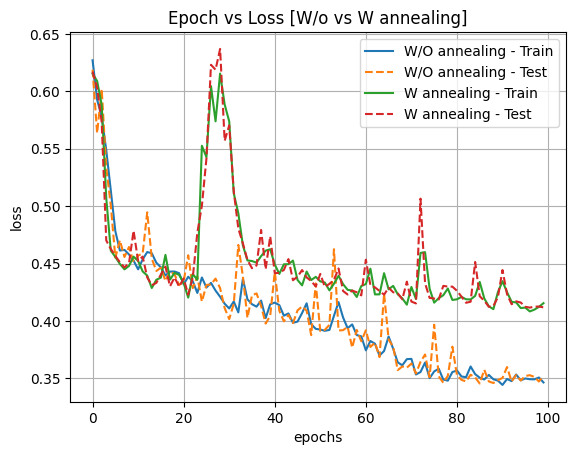

In [8]:
plt.plot(wo_epoch_loss_track, label = "W/O annealing - Train")
plt.plot(wo_epoch_loss_track_test, label = "W/O annealing - Test", linestyle = "--")

plt.plot(w_epoch_loss_track, label = "W annealing - Train")
plt.plot(w_epoch_loss_track_test, label = "W annealing - Test", linestyle = "--")

plt.legend()
plt.xlabel("epochs")
plt.ylabel("loss")

# plt.yscale("log")
# plt.ylim((0, 4))
plt.grid()

plt.title("Epoch vs Loss [W/o vs W annealing]")

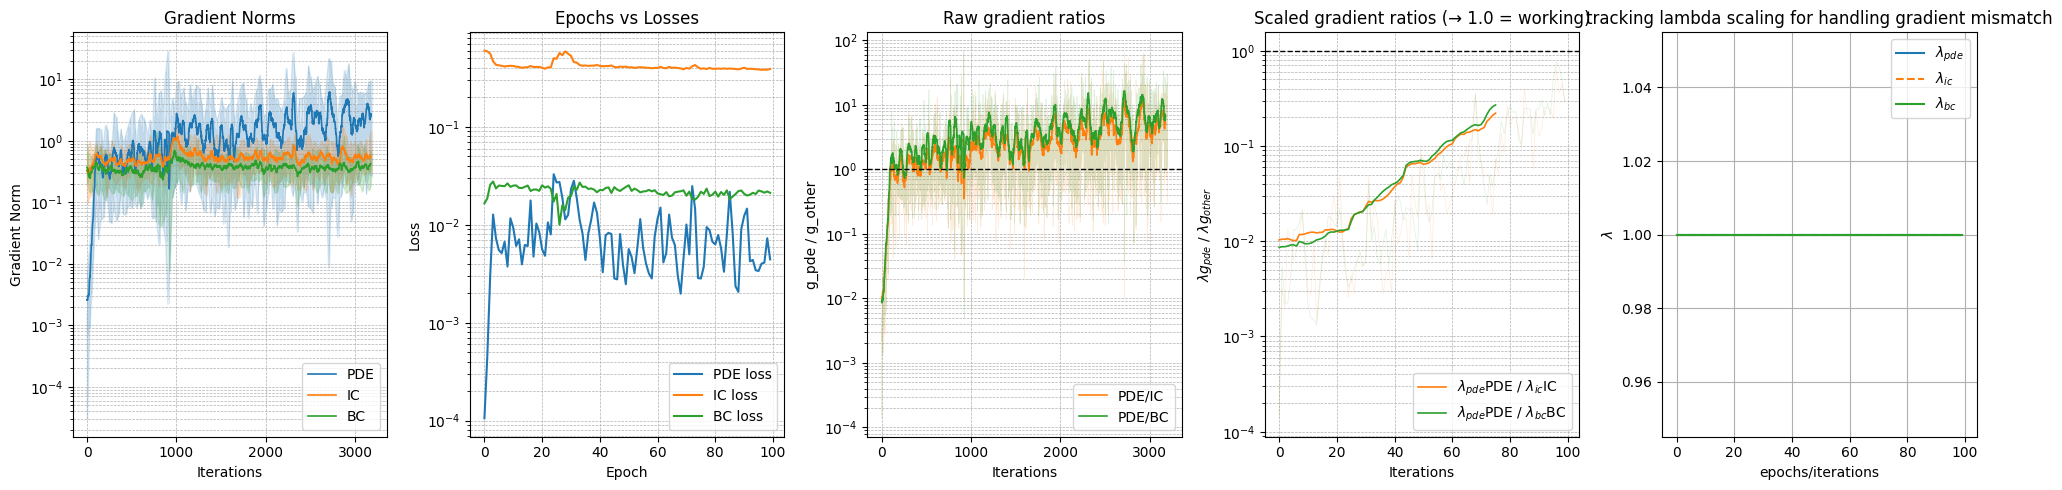

In [9]:
plot_gradients_and_losses(w_grad_tracker, w_residue_tracker, w_lambda_tracker, window=25)

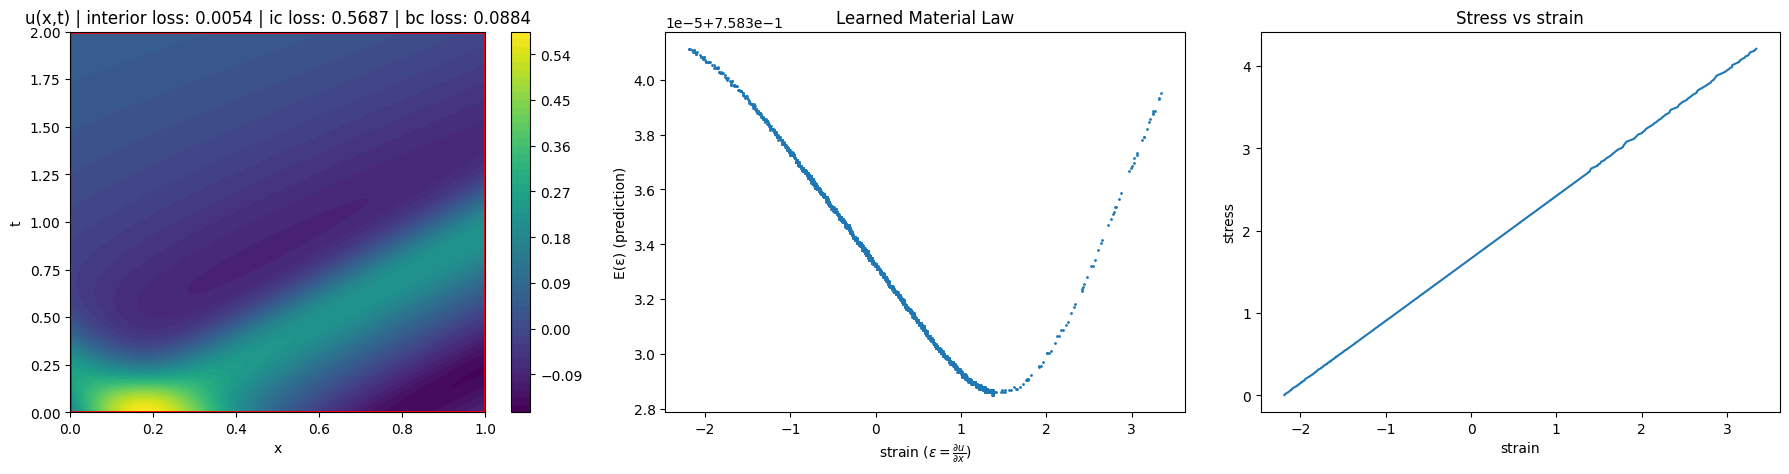

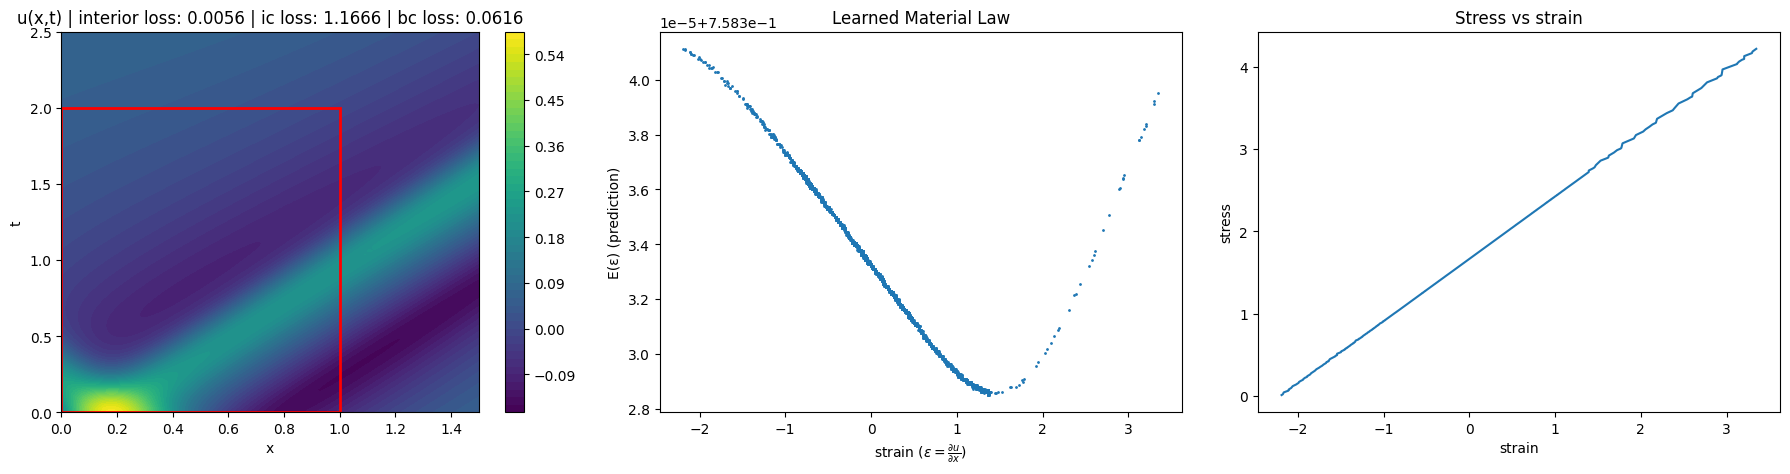

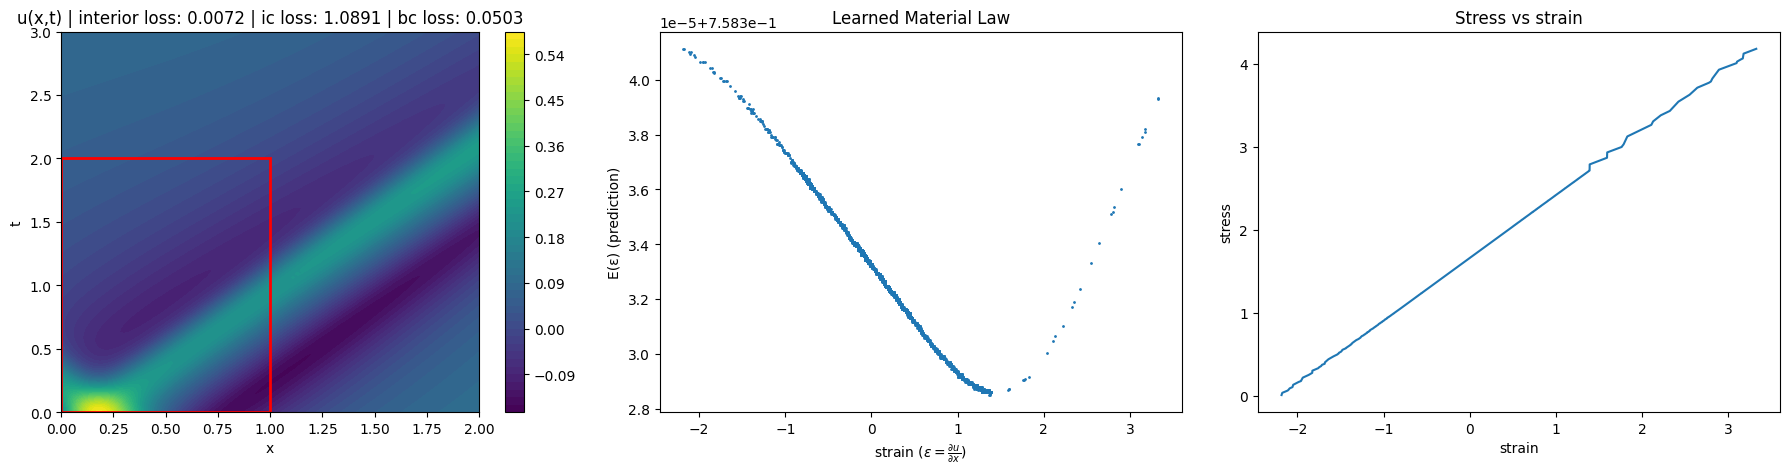

In [10]:
inference(domain = domain, 
          u_model = u_predictor_model, 
          E_model = E_predictor_model, 
          u_0 = u_0, v_0 = v_0)

inference(domain = torch.tensor([[0, 1.5], [0, 2.5]]), 
          u_model = u_predictor_model, 
          E_model = E_predictor_model, 
          u_0 = u_0, v_0 = v_0)

inference(domain = torch.tensor([[0, 2], [0, 3]]), 
          u_model = u_predictor_model, 
          E_model = E_predictor_model, 
          u_0 = u_0, v_0 = v_0)


In [11]:
lr = 1e-4
u_predictor_model = NN(input_dim = 2, output_dim = 1, layers = 8, neurons = 128)
E_predictor_model = NN(input_dim = 1, output_dim = 1, layers = 8, neurons = 128)

optimizer = torch.optim.Adam(
    list(u_predictor_model.parameters()) + 
    list(E_predictor_model.parameters()),
    lr=lr
)

w_g_epoch_loss_track, w_g_epoch_loss_track_test, w_g_residue_tracker, w_g_grad_tracker, w_g_lambda_tracker = train(
                                                                                           epochs = 100, optimizer = optimizer, 
                                                                                           u_predictor_model = u_predictor_model, 
                                                                                           E_predictor_model = E_predictor_model, 
                                                                                           train_dataloader = train_dataloader, test_dataloader = test_dataloader, 
                                                                                           get_interior = get_interior, get_initial = get_initial, get_BC = get_BC,
                                                                                           get_interior_residual = get_interior_residual, get_IC_residue = get_IC_residue, get_BC_residue = get_BC_residue, 
                                                                                           domain = domain,
                                                                                           u_0 = u_0, v_0 = v_0,
                                                                                           lr_annealing_decay = True,
                                                                                           initial_lr=lr,
                                                                                           lambda_scaling = True
                                                                                           )

EPOCH: 1 | train loss: 0.6256 | test loss: 0.6177
EPOCH: 11 | train loss: 0.5993 | test loss: 0.5993
EPOCH: 21 | train loss: 0.5965 | test loss: 0.6012
EPOCH: 31 | train loss: 0.4630 | test loss: 0.4686
EPOCH: 41 | train loss: 0.4495 | test loss: 0.4543
EPOCH: 51 | train loss: 0.4466 | test loss: 0.4509
EPOCH: 61 | train loss: 0.4467 | test loss: 0.4514
EPOCH: 71 | train loss: 0.4474 | test loss: 0.4522
EPOCH: 81 | train loss: 0.4485 | test loss: 0.4490
EPOCH: 91 | train loss: 0.4421 | test loss: 0.4476
EPOCH: 100 | train loss: 0.4509 | test loss: 0.4498


In [12]:
w_g_lambda_tracker['pde'][-1], w_g_lambda_tracker['ic'][-1], w_g_lambda_tracker['bc'][-1]

(1.0, 0.9999999907670298, 2.614115358303777)

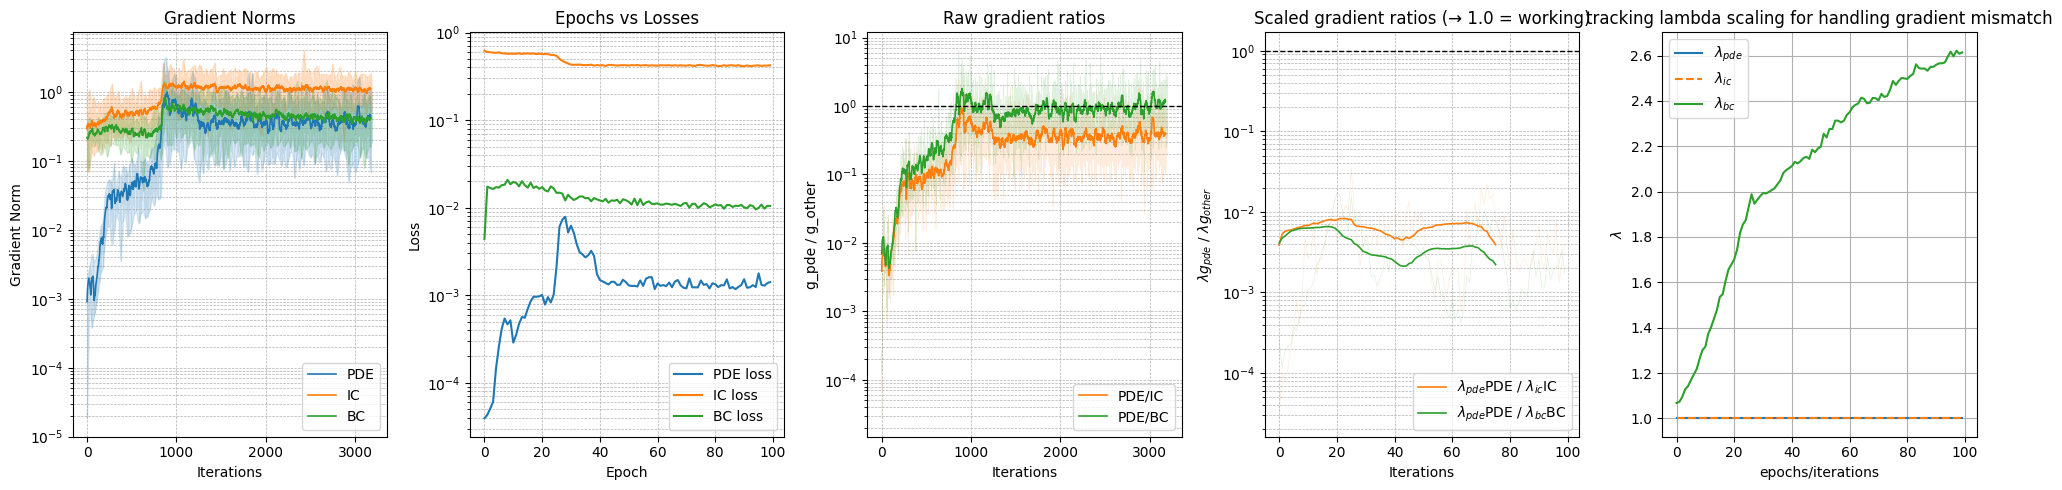

In [13]:
plot_gradients_and_losses(w_g_grad_tracker, w_g_residue_tracker, w_g_lambda_tracker, window=25)

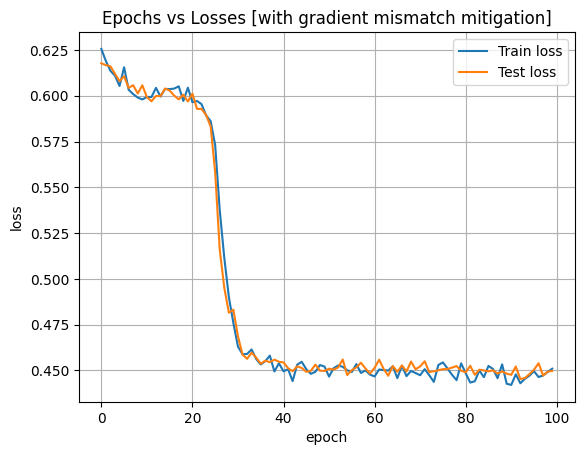

In [14]:
plt.plot(w_g_epoch_loss_track, label = "Train loss")
plt.plot(w_g_epoch_loss_track_test, label = "Test loss")

plt.title("Epochs vs Losses [with gradient mismatch mitigation]")
plt.xlabel("epoch")
plt.ylabel("loss")

plt.grid()
plt.legend()

plt.show()

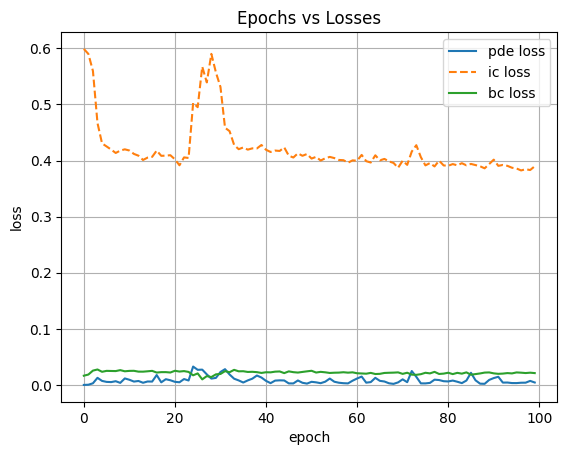

In [15]:
pde_loss = [v[0] for k, v in w_residue_tracker.items()]
ic_loss = [v[1] for k, v in w_residue_tracker.items()]
bc_loss = [v[2] for k, v in w_residue_tracker.items()]

plt.plot(pde_loss, label = "pde loss")
plt.plot(ic_loss, label = "ic loss", linestyle = "--")
plt.plot(bc_loss, label = "bc loss")

plt.title("Epochs vs Losses")
plt.xlabel("epoch")
plt.ylabel("loss")

plt.grid()
plt.legend()

# plt.yscale('log')

plt.show()

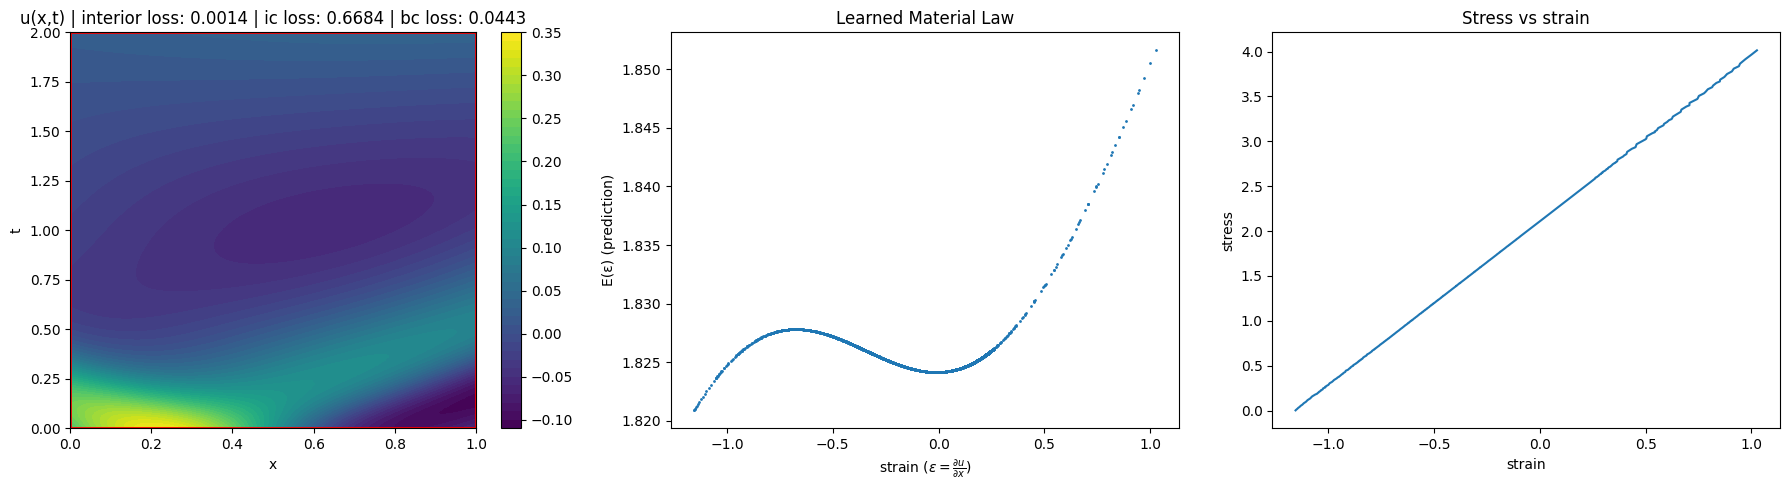

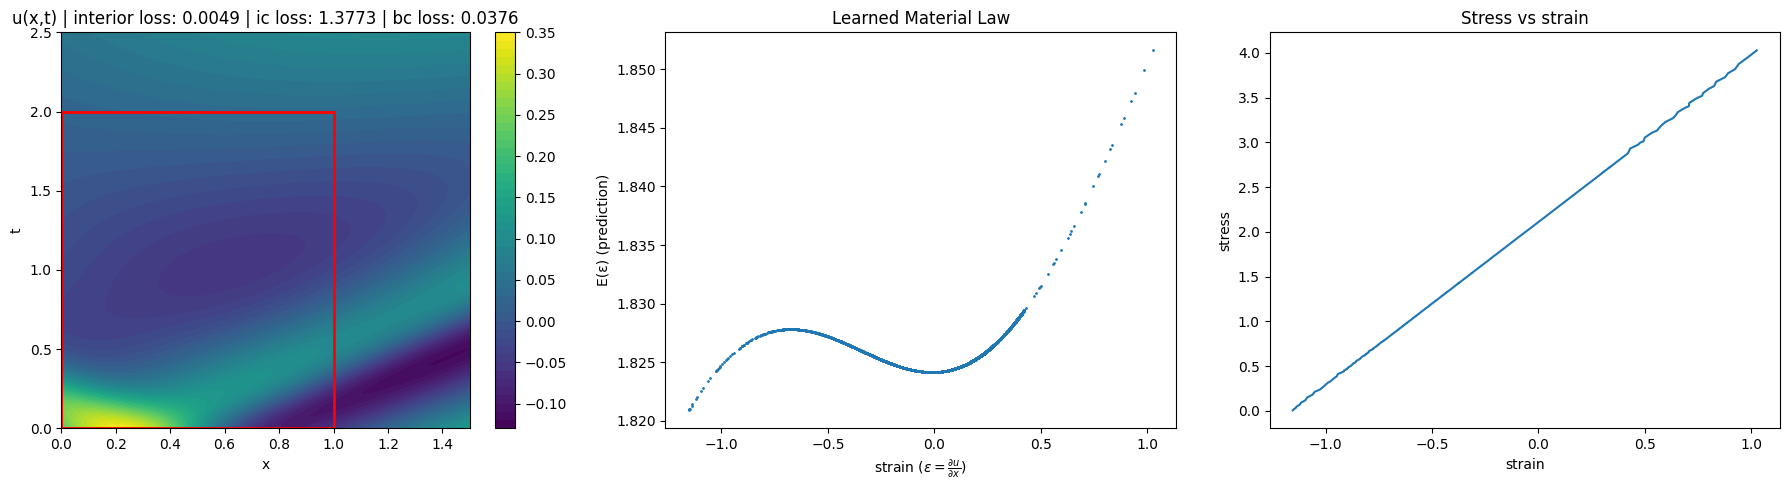

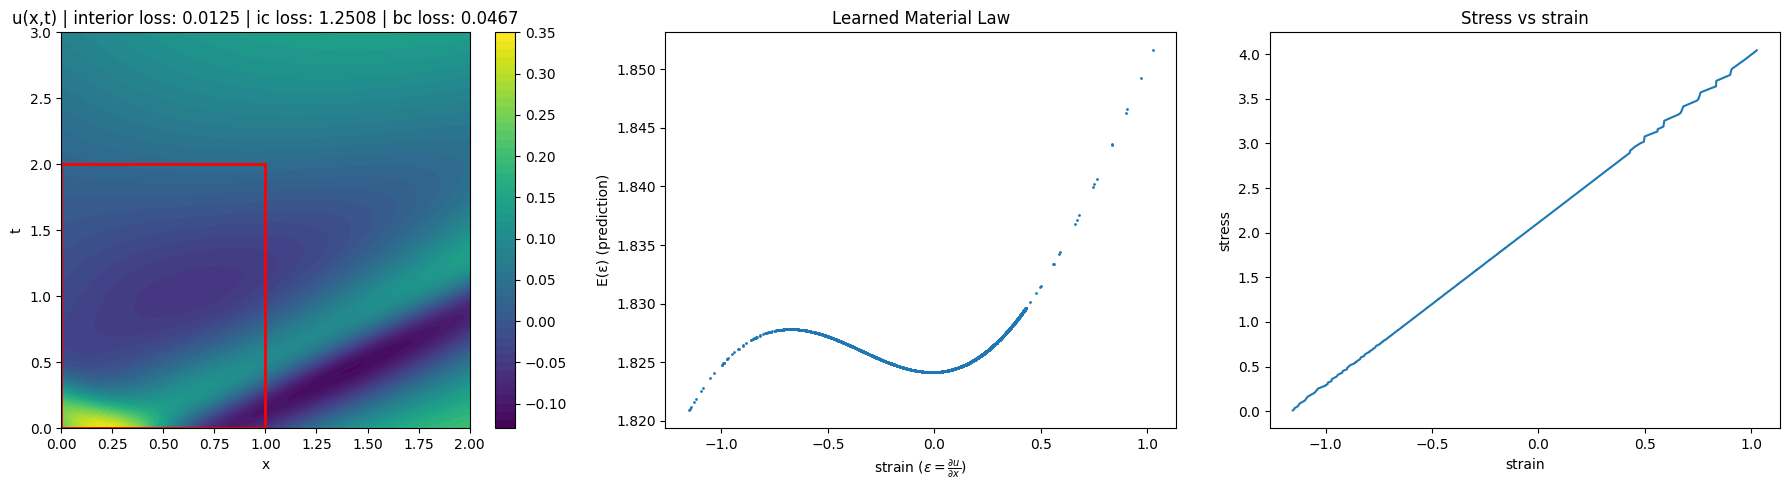

In [16]:
inference(domain = domain, 
          u_model = u_predictor_model, 
          E_model = E_predictor_model, 
          u_0 = u_0, v_0 = v_0)

inference(domain = torch.tensor([[0, 1.5], [0, 2.5]]), 
          u_model = u_predictor_model, 
          E_model = E_predictor_model, 
          u_0 = u_0, v_0 = v_0)

inference(domain = torch.tensor([[0, 2], [0, 3]]), 
          u_model = u_predictor_model, 
          E_model = E_predictor_model, 
          u_0 = u_0, v_0 = v_0)
